In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from google.colab import files
from IPython.display import Image, display
import cv2
from PIL import Image as PILImage
import io

In [ ]:
# Load the PlantVillage dataset from TFDS
# This will download the dataset (~1.2GB) if not already cached
dataset_name = 'plant_village'
(ds_train, ds_test), ds_info = tfds.load(
    dataset_name,
    split=['train[:80%]', 'train[80%:]'],  # Use 80-20 split
    as_supervised=True,
    with_info=True
)

# Get class names
class_names = ds_info.features['label'].names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print("Sample classes:", class_names[:5])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.PD7SJU_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Number of classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
# ResNet50 expects images of size 224x224 and normalized to [0,1]
IMG_SIZE = 224

def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
    return image, label

# Apply preprocessing
ds_train = ds_train.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Shuffle, batch, prefetch
ds_train = ds_train.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Optional: Display a batch
for images, labels in ds_train.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [ ]:
# Load pre-trained ResNet50 without top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base model layers initially
base_model.trainable = False

# Add custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,022 (92.02 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

EPOCHS = 2  # Increase for better accuracy, but 5 is enough for demo

history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/2
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 9666s 7s/step - accuracy: 0.1166 - loss: 3.3401 - val_accuracy: 0.1958 - val_loss: 2.9767
Epoch 2/2
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 9680s 7s/step - accuracy: 0.1810 - loss: 3.0447 - val_accuracy: 0.2666 - val_loss: 2.8119


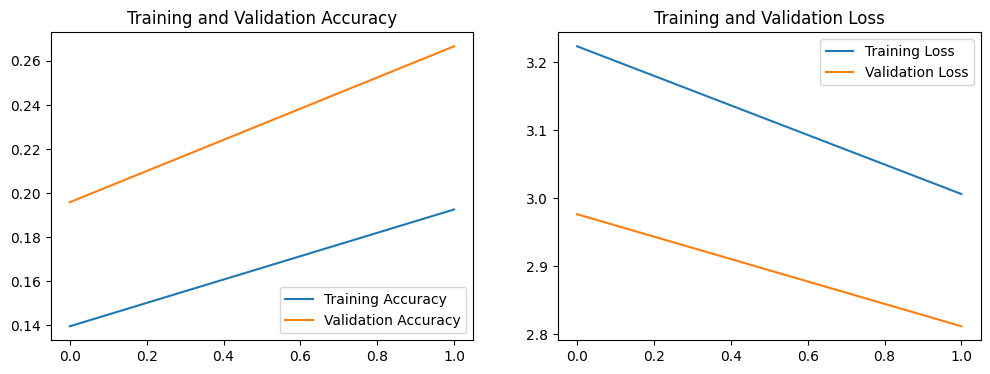

In [ ]:
# Plot training & validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
def predict_uploaded_image(model, class_names):
    uploaded = files.upload()
    for filename in uploaded.keys():
        # Display the uploaded image
        display(Image(filename=filename, width=300))

        # Load and preprocess the image
        img = PILImage.open(io.BytesIO(uploaded[filename])).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Predict
        predictions = model.predict(img_array)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])

        print(f"Predicted Disease: {class_names[predicted_class]}")
        print(f"Confidence: {confidence:.2f}")

In [ ]:
# Take one image from test set and predict
for image, label in ds_test.unbatch().take(1):
    img_array = np.expand_dims(image.numpy(), axis=0)
    pred = model.predict(img_array)
    pred_class = np.argmax(pred[0])
    true_class = label.numpy()
    print(f"True: {class_names[true_class]}, Predicted: {class_names[pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
True: Tomato___healthy, Predicted: Orange___Haunglongbing_(Citrus_greening)


In [ ]:
# Run this cell and upload a plant leaf image
predict_uploaded_image(model, class_names)